# Training Modelli

Notebook di allenamento per i vari modelli scelti, EyeSeeNet-MobileNetV2-EfficientNetB0-ResNet50V2.

## Ambiente

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT ='/content/drive/MyDrive/Progetto Deep Learning EyeSee'
import os
os.chdir(PROJECT_ROOT)

print("Cartella corrente:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cartella corrente: /content/drive/MyDrive/Progetto Deep Learning EyeSee


In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

In [ ]:
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

NumPy: 2.1.3
pandas: 2.2.3
TensorFlow: 2.20.0
Matplotlib: 3.10.0


In [ ]:
MODEL_CONFIGS = {
    "MobileNetV2": {
        "constructor": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "unfreeze_block": "block_16",

    },
    "EfficientNetB0": {
        "constructor": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "unfreeze_block": "block7a",
    },
    "ResNet50V2": {
        "constructor": tf.keras.applications.ResNet50V2,
        "preprocess": tf.keras.applications.resnet_v2.preprocess_input,
        "unfreeze_block": "conv5_block3",
    },

}
INPUT_SIZE= (224, 224, 3)

qua sotto c'è la funzione utilizzata per controllare i vari blocchi presenti e quindi scegliere quali scongelare, in questo caso abbiamo scelto solamente l'ultimo blocco

In [ ]:
#_, conv_base_mn = build_model("ResNet50V2")
#for layer in conv_base_mn.layers:
#    print(layer.name)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory("data/dataset_split/train", image_size=(224, 224), batch_size=32, seed=SEED)
validation_dataset = tf.keras.utils.image_dataset_from_directory("data/dataset_split/validation", image_size=(224, 224), batch_size=32, seed=SEED)

Found 2951 files belonging to 4 classes.
Found 633 files belonging to 4 classes.


In [ ]:
#controllo dei nomi delle classi
class_names = train_dataset.class_names
print(class_names)

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


##Funzioni

In [ ]:
def build_conv_base(model_name):
    config = MODEL_CONFIGS[model_name]

    conv_base = config["constructor"](
        weights="imagenet", #caricamento dei pesi di imagenet
        include_top=False,
        input_shape=(INPUT_SIZE)
    )

    # Congelamento iniziale
    conv_base.trainable = False

    return conv_base

In [ ]:
def build_model(model_name, dropout, num_classes=4):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    config = MODEL_CONFIGS[model_name]
    conv_base = build_conv_base(model_name)

    inputs = tf.keras.Input(shape=(INPUT_SIZE))

    # Scaling dei valori (preprocessing specifico per modello)
    x = tf.keras.layers.Lambda(config["preprocess"])(inputs)

    x = conv_base(x)
    # Nuova head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)
    return model, conv_base

In [ ]:
def unfreeze_from_block(conv_base, block_name):
    conv_base.trainable = True
    unfreeze = False
    block_found = False
    for layer in conv_base.layers:
        if block_name in layer.name: #da quel layer in poi diventa allenabile
            unfreeze = True
            block_found = True
        layer.trainable = unfreeze
        if isinstance(layer, tf.keras.layers.BatchNormalization): #evita di scongelare i layer di batch normalization
            layer.trainable = False

    if not block_found:
        raise ValueError( #così la cella si blocca
            f"Nessun layer contiene '{block_name}' in {conv_base.name}. "
            f"Controlla il nome del blocco in MODEL_CONFIGS."
        )

In [ ]:
def iperparameter_search(model_name, step, epochs=4):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    if step==1: #separazione in step a causa della caduta del runtime
      lrs = [1e-3]
    else:
      lrs = [1e-4]
    dropouts = [0.2, 0.4]

    results_search = {}
    best_run = None
    best_val_loss = float("inf")

    for lr in lrs:
        for dropout in dropouts:
            run_name = f"lr{lr}_drop{dropout}"
            print(f"\n{model_name} - lr={lr}, dropout={dropout}")

            model, conv_base = build_model(model_name, dropout=dropout)

            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                metrics=["accuracy"]
            )

            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=validation_dataset
            )

            val_loss = min(history.history["val_loss"])
            val_acc = max(history.history["val_accuracy"])
            results_search[run_name] = {"lr": lr, "dropout": dropout, "val_loss": val_loss, "val_accuracy": val_acc, "weights":model.get_weights()}

            print(f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}") #valori migliori ottenuti (in generale non come tupla)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_run = run_name


    print(f"\nMigliore: {best_run}")

    return results_search[best_run]

In [ ]:
def iperparameter_search_ft(model, model_name, epochs=4):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    lrs = [1e-4, 1e-5]

    results_search = {}
    best_run = None
    best_val_loss = float("inf")

    initial_weights = model.get_weights() #reset dei pesi è più leggero rispetto a dover ricaricare il modello
    for lr in lrs:
        print(f"\n{model_name} - lr={lr}")
        run_name = f"lr{lr}"
        model.set_weights(initial_weights)

        model.compile(
            loss="sparse_categorical_crossentropy",
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            metrics=["accuracy"]
        )

        callbacks = tf.keras.callbacks.EarlyStopping( #aggiunta sorprendente a causa della velocità di allenamento di certi modelli
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
        )

        history = model.fit(
            train_dataset,
            epochs=epochs,
            validation_data=validation_dataset,
            callbacks=callbacks
        )
        val_loss = min(history.history["val_loss"])
        val_acc = max(history.history["val_accuracy"])
        results_search[run_name] = {"lr": lr, "val_loss": val_loss, "val_accuracy": val_acc, "weights":model.get_weights()}

        print(f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_run = run_name

    print(f"\nMigliore: {best_run}")
    model.set_weights(initial_weights)
    return results_search[best_run]

In [ ]:
def train_model(model, model_name, lr, step, epochs=10, ft=False, patience=3):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    #path in cui salvare il modello in caso sia finetuning
    if ft:
      model_path=f"results/models/{model_name}_ft{step}.keras"
    else:
      model_path=f"results/models/{model_name}_top{step}.keras"

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            save_best_only=True,
            monitor="val_loss"
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    ]

    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=validation_dataset,
        callbacks=callbacks
    )
    return model, history

In [ ]:
def plot_history(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "bo", label="Accuratezza in addestramento")
    plt.plot(epochs, val_accuracy, "b", label="Accuratezza in validazione")
    plt.title("Accuratezza in addestramento e validazione")
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, "bo", label="Loss in addestramento")
    plt.plot(epochs, val_loss, "b", label="Loss in validazione")
    plt.title("Loss in addestramento e validazione")
    plt.legend()

    plt.show()
    #codice ottenuto dal notebook della Settimana 2 di Deeplearning di Mirko Marras

##EyeSeeNet

#### Funzioni

In [ ]:
def build_ESN(dropout, num_classes=4):
  inputs = tf.keras.Input(shape=INPUT_SIZE)
  x = tf.keras.layers.Rescaling(1./255)(inputs) #rescaling molto semplice

  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
  x = tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
  x = tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
  x = tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
  x = tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

  x = tf.keras.layers.GlobalAveragePooling2D()(x)
  x = tf.keras.layers.Dense(256, activation="relu")(x)
  x = tf.keras.layers.Dropout(dropout)(x)
  outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)


  model = tf.keras.Model(inputs=inputs, outputs=outputs)
  return model

In [ ]:
def iperparameter_search_ESN(step, epochs=4):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    if step==1: #split a causa della disconnessione del runtime
      lrs = [1e-3]
    else:
      lrs = [1e-4]
    dropouts = [0.2, 0.4]

    results_search = {}
    best_run = None
    best_val_loss = float("inf")

    for lr in lrs:
        for dropout in dropouts:
            run_name = f"lr{lr}_drop{dropout}"
            print(f"\nEyeSeeNet - lr={lr}, dropout={dropout}")

            model = build_ESN(dropout=dropout)

            model.compile(
                loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                metrics=["accuracy"]
            )

            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=validation_dataset
            )

            val_loss = min(history.history["val_loss"])
            val_acc = max(history.history["val_accuracy"])
            results_search[run_name] = {"lr": lr, "dropout": dropout, "val_loss": val_loss, "val_accuracy": val_acc, "weights": model.get_weights()}

            print(f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_run = run_name


    print(f"\nMigliore: {best_run}")

    return results_search[best_run]

In [ ]:
def train_ESN(model, lr, step, epochs=10, patience=5):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"results/models/EyeSeeNet_step{step}.keras",
            save_best_only=True,
            monitor="val_loss"
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    ]

    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=validation_dataset,
        callbacks=callbacks
    )
    return model, history

####iperparametri


In [ ]:
result_ESN1 = iperparameter_search_ESN(step=1)


EyeSeeNet - lr=0.001, dropout=0.2
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 473s 5s/step - accuracy: 0.2843 - loss: 1.3663 - val_accuracy: 0.3870 - val_loss: 1.2986
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 496s 5s/step - accuracy: 0.4426 - loss: 1.1713 - val_accuracy: 0.4360 - val_loss: 1.1305
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 497s 5s/step - accuracy: 0.4822 - loss: 1.0808 - val_accuracy: 0.4724 - val_loss: 1.1002
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 503s 5s/step - accuracy: 0.5012 - loss: 1.0272 - val_accuracy: 0.5419 - val_loss: 0.9520
val_loss: 0.9520 - val_accuracy: 0.5419

EyeSeeNet - lr=0.001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 455s 5s/step - accuracy: 0.3440 - loss: 1.3241 - val_accuracy: 0.3886 - val_loss: 1.2423
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 462s 5s/step - accuracy: 0.4581 - loss: 1.1713 - val_accuracy: 0.4629 - val_loss: 1.1089
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 461s 5s/step - accuracy: 0.4744 - loss: 1.0799 - val_accuracy: 0.5118 - val_loss: 1.0728
Epoch 4/

In [ ]:
model_esn= build_ESN(dropout=result_ESN1["dropout"])
model_esn.set_weights(result_ESN1["weights"])
model_esn.save("results/models/EyeSeeNet_ip1.keras")

In [ ]:
result_ESN2 = iperparameter_search_ESN(step=2)


EyeSeeNet - lr=0.0001, dropout=0.2
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 476s 5s/step - accuracy: 0.3175 - loss: 1.3553 - val_accuracy: 0.3507 - val_loss: 1.2840
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 503s 5s/step - accuracy: 0.4110 - loss: 1.2317 - val_accuracy: 0.4329 - val_loss: 1.1947
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 458s 5s/step - accuracy: 0.4456 - loss: 1.1782 - val_accuracy: 0.4613 - val_loss: 1.1527
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 511s 5s/step - accuracy: 0.4802 - loss: 1.1411 - val_accuracy: 0.4739 - val_loss: 1.1616
val_loss: 1.1527 - val_accuracy: 0.4739

EyeSeeNet - lr=0.0001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 469s 5s/step - accuracy: 0.3212 - loss: 1.3566 - val_accuracy: 0.3807 - val_loss: 1.3037
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 450s 5s/step - accuracy: 0.3972 - loss: 1.2578 - val_accuracy: 0.4013 - val_loss: 1.2131
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 458s 5s/step - accuracy: 0.4439 - loss: 1.1933 - val_accuracy: 0.4534 - val_loss: 1.1885
Epoch 

In [ ]:
model_esn2= build_ESN(dropout=result_ESN2["dropout"])
model_esn2.set_weights(result_ESN2["weights"])
model_esn2.save("results/models/EyeSeeNet_ip2.keras")

In [ ]:
model_esn.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

model_esn2.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

res1_loss, _ = model_esn.evaluate(validation_dataset)
res2_loss, _ = model_esn2.evaluate(validation_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5419 - loss: 0.9520
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.4787 - loss: 1.1416


In [ ]:
if res1_loss<res2_loss:
  best=model_esn
  print(f"{result_ESN1["lr"]} {result_ESN1["dropout"]}")
  result_ESN=result_ESN1
else:
  best=model_esn2
  print(f"{result_ESN2["lr"]} {result_ESN2["dropout"]}")
  result_ESN=result_ESN2
best.save("results/models/EyeSeeNet_ip.keras")

0.001 0.2


####training

In [ ]:
model_esn = tf.keras.models.load_model(f"results/models/EyeSeeNet_ip.keras")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



EyeSeeNet - parte1

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 470s 5s/step - accuracy: 0.5774 - loss: 0.8530 - val_accuracy: 0.5908 - val_loss: 0.8173
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 490s 5s/step - accuracy: 0.6313 - loss: 0.7562 - val_accuracy: 0.6161 - val_loss: 0.7812
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 467s 5s/step - accuracy: 0.6337 - loss: 0.7547 - val_accuracy: 0.6193 - val_loss: 0.7517
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 508s 5s/step - accuracy: 0.6306 - loss: 0.7306 - val_accuracy: 0.6256 - val_loss: 0.7431
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 493s 5s/step - accuracy: 0.6537 - loss: 0.7095 - val_accuracy: 0.6114 - val_loss: 0.8059
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 462s 5s/step - accuracy: 0.6479 - loss: 0.7178 - val_accuracy: 0.6730 - val_loss: 0.7109
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 453s 5s/step - accuracy: 0.6652 - loss: 0.6856 - val_accuracy: 0.6872 - val_loss: 0.7189
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.6679 - loss: 0.6860 - val

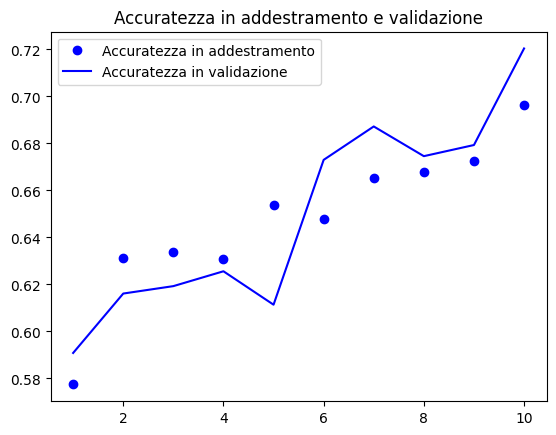

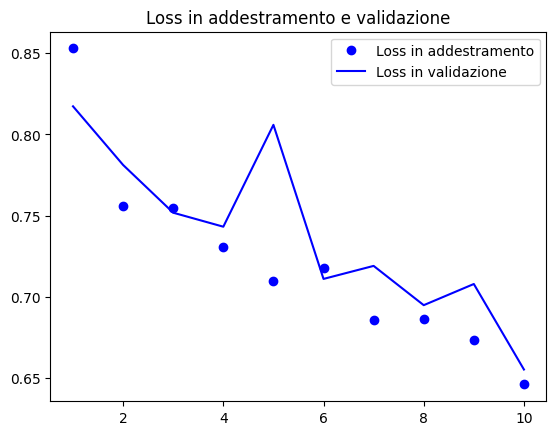

In [ ]:

print("\nEyeSeeNet - parte1\n")
model_esn, history_esn1= train_ESN(model_esn, lr=result_ESN["lr"], step=1)

plot_history(history_esn1)

In [ ]:
#in caso di reset runtime
#model_esn = tf.keras.models.load_model(f"results/models/EyeSeeNet_step1.keras")


EyeSeeNet - parte2

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 454s 5s/step - accuracy: 0.7282 - loss: 0.6090 - val_accuracy: 0.7330 - val_loss: 0.5987
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 462s 5s/step - accuracy: 0.7530 - loss: 0.5742 - val_accuracy: 0.7504 - val_loss: 0.5901
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 465s 5s/step - accuracy: 0.7709 - loss: 0.5285 - val_accuracy: 0.7867 - val_loss: 0.5387
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 467s 5s/step - accuracy: 0.7882 - loss: 0.4820 - val_accuracy: 0.7883 - val_loss: 0.5345
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 468s 5s/step - accuracy: 0.8123 - loss: 0.4612 - val_accuracy: 0.7741 - val_loss: 0.5276
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 540s 5s/step - accuracy: 0.8268 - loss: 0.4228 - val_accuracy: 0.8452 - val_loss: 0.4685
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 455s 5s/step - accuracy: 0.8394 - loss: 0.3866 - val_accuracy: 0.8531 - val_loss: 0.4322
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.8363 - loss: 0.3855 - val

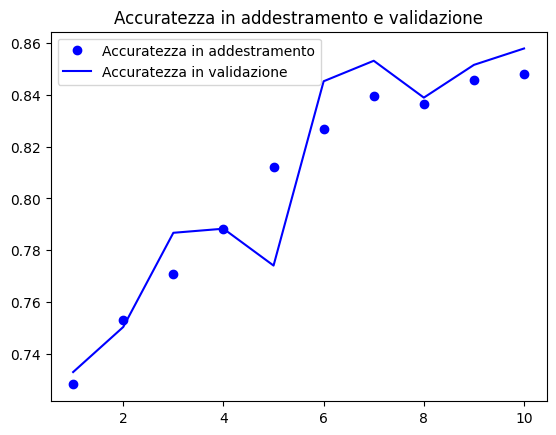

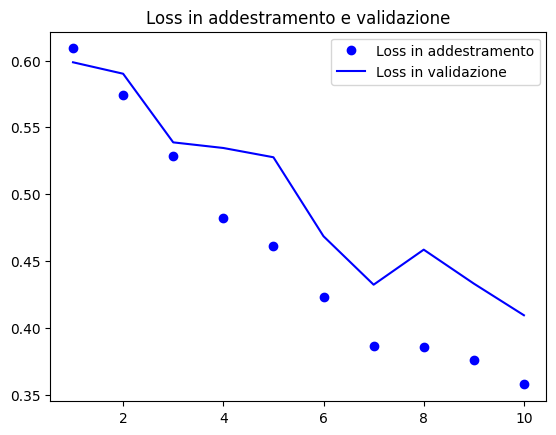

In [ ]:
print("\nEyeSeeNet - parte2\n")
model_esn, history_esn2=train_ESN(model_esn, lr=result_ESN["lr"], step=2)
plot_history(history_esn2)

In [ ]:
#in caso di reset runtime
#model_esn = tf.keras.models.load_model(f"results/models/EyeSeeNet_step2.keras")


EyeSeeNet - parte3

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 476s 5s/step - accuracy: 0.8600 - loss: 0.3498 - val_accuracy: 0.8515 - val_loss: 0.4284
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 459s 5s/step - accuracy: 0.8614 - loss: 0.3433 - val_accuracy: 0.8341 - val_loss: 0.4613
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 461s 5s/step - accuracy: 0.8753 - loss: 0.3199 - val_accuracy: 0.8705 - val_loss: 0.3968
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 501s 5s/step - accuracy: 0.8743 - loss: 0.3086 - val_accuracy: 0.8357 - val_loss: 0.4343
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 471s 5s/step - accuracy: 0.8661 - loss: 0.3272 - val_accuracy: 0.8863 - val_loss: 0.3851
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 499s 5s/step - accuracy: 0.8814 - loss: 0.3111 - val_accuracy: 0.8768 - val_loss: 0.3807
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 467s 5s/step - accuracy: 0.8841 - loss: 0.2900 - val_accuracy: 0.8784 - val_loss: 0.3675
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 491s 5s/step - accuracy: 0.8828 - loss: 0.2972 - val

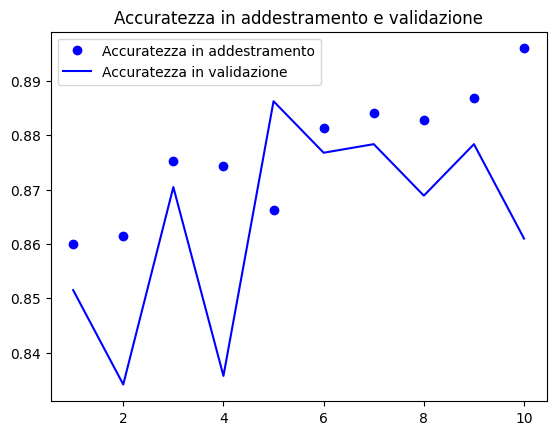

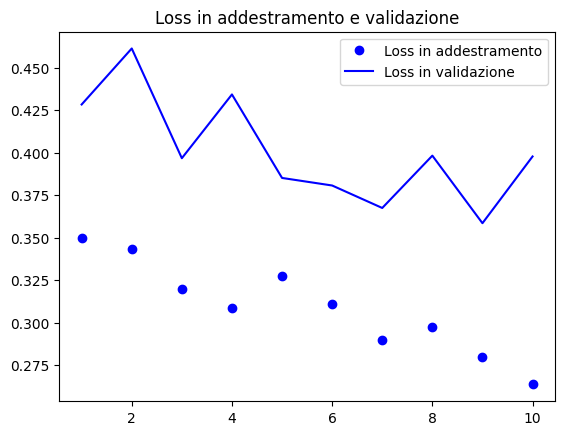

In [ ]:
print("\nEyeSeeNet - parte3\n")
model_esn, history_esn3=train_ESN(model_esn, lr=result_ESN["lr"], step=3)
plot_history(history_esn3)

In [ ]:
#in caso di reset runtime
#model_esn = tf.keras.models.load_model(f"results/models/EyeSeeNet_step3.keras")

In [ ]:
print("\nEyeSeeNet - parte 4\n")
model_esn, history_esn4=train_ESN(model_esn, lr=result_ESN["lr"], step=4)
plot_history(history_esn4)


EyeSeeNet - parte 4

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 453s 5s/step - accuracy: 0.8885 - loss: 0.2931 - val_accuracy: 0.8562 - val_loss: 0.4088
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 460s 5s/step - accuracy: 0.8980 - loss: 0.2591 - val_accuracy: 0.8752 - val_loss: 0.3878
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 442s 5s/step - accuracy: 0.8946 - loss: 0.2636 - val_accuracy: 0.8689 - val_loss: 0.4044
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 521s 5s/step - accuracy: 0.8963 - loss: 0.2515 - val_accuracy: 0.8784 - val_loss: 0.3613
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 465s 5s/step - accuracy: 0.9024 - loss: 0.2459 - val_accuracy: 0.8752 - val_loss: 0.3884
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 487s 5s/step - accuracy: 0.9041 - loss: 0.2475 - val_accuracy: 0.8705 - val_loss: 0.3881
Epoch 7/10
 7/93 ━━━━━━━━━━━━━━━━━━━━ 6:35 5s/step - accuracy: 0.9386 - loss: 0.1842

##MobileNetV2

In [ ]:
model_name = "MobileNetV2"

###Top

#### iperparametri

In [ ]:
result_mobilenet1=iperparameter_search(model_name, step=1)


MobileNetV2 - lr=0.001, dropout=0.2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.7472 - loss: 0.6331 - val_accuracy: 0.7915 - val_loss: 0.5042
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8448 - loss: 0.4110 - val_accuracy: 0.8531 - val_loss: 0.3871
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8675 - loss: 0.3426 - val_accuracy: 0.8436 - val_loss: 0.3997
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8919 - loss: 0.2986 - val_accuracy: 0.8483 - val_loss: 0.3734
val_loss: 0.3734 - val_accuracy: 0.8531

MobileNetV2 - lr=0.001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.7343 - loss: 0.6581 - val_accuracy: 0.8373 - val_loss: 0.4429
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8241 - loss: 0.4480 - val_accuracy: 0.8389 - val_loss: 0.4123
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8526 - loss: 0.38

In [ ]:
model_mn, conv_base_mn = build_model(model_name, dropout=result_mobilenet1["dropout"])
model_mn.set_weights(result_mobilenet1["weights"])
model_mn.save(f"results/models/{model_name}_ip1.keras")

In [ ]:
result_mobilenet2=iperparameter_search(model_name, step=2)


MobileNetV2 - lr=0.0001, dropout=0.2
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.6571 - loss: 0.8435 - val_accuracy: 0.7852 - val_loss: 0.5808
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.7852 - loss: 0.5650 - val_accuracy: 0.8104 - val_loss: 0.5008
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.8126 - loss: 0.4876 - val_accuracy: 0.8404 - val_loss: 0.4490
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8384 - loss: 0.4410 - val_accuracy: 0.8499 - val_loss: 0.4215
val_loss: 0.4215 - val_accuracy: 0.8499

MobileNetV2 - lr=0.0001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6032 - loss: 0.9308 - val_accuracy: 0.7694 - val_loss: 0.6244
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7580 - loss: 0.6204 - val_accuracy: 0.8025 - val_loss: 0.5342
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.7909 - loss: 0.5415 - val_accuracy: 0.8215 - val_loss: 0.4851
Ep

In [ ]:
model_mn2, conv_base_mn2 = build_model(model_name, dropout=result_mobilenet2["dropout"])
model_mn2.set_weights(result_mobilenet2["weights"])
model_mn2.save(f"results/models/{model_name}_ip2.keras")

In [ ]:
model_mn.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

model_mn2.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

res1_loss, _ = model_mn.evaluate(validation_dataset)
res2_loss, _ = model_mn2.evaluate(validation_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8736 - loss: 0.3336
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8499 - loss: 0.4215


In [ ]:
if res1_loss<res2_loss: #comparazione fra i modelli
  best=model_mn
  print(f"{result_mobilenet1["lr"]} {result_mobilenet1["dropout"]}")
  result_mobilenet=result_mobilenet1
else:
  best=model_mn2
  print(f"{result_mobilenet2["lr"]} {result_mobilenet2["dropout"]}")
  result_mobilenet=result_mobilenet2
best.save(f"results/models/{model_name}_ip.keras")

0.001 0.4


#### training


MobileNetV2 - parte1

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


93/93 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8763 - loss: 0.3283 - val_accuracy: 0.8720 - val_loss: 0.3241
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8926 - loss: 0.2785 - val_accuracy: 0.8720 - val_loss: 0.3284
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9065 - loss: 0.2508 - val_accuracy: 0.8720 - val_loss: 0.3248
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9055 - loss: 0.2423 - val_accuracy: 0.8768 - val_loss: 0.3226
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9126 - loss: 0.2215 - val_accuracy: 0.8878 - val_loss: 0.3123
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9197 - loss: 0.2012 - val_accuracy: 0.8531 - val_loss: 0.3763
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9193 - loss: 0.2070 - val_accuracy: 0.8673 - val_loss: 0.3196
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9373 - loss: 0.1762 - val_accuracy: 0.8768 - val_loss: 0.

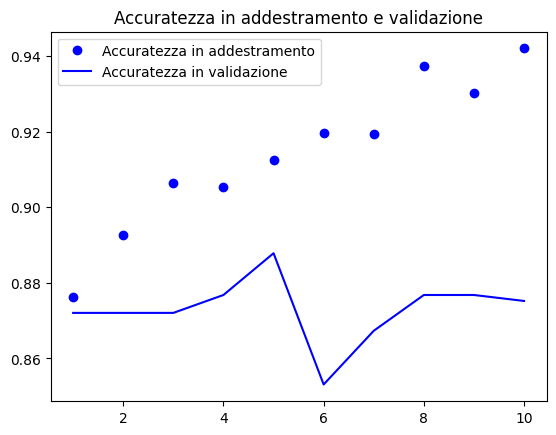

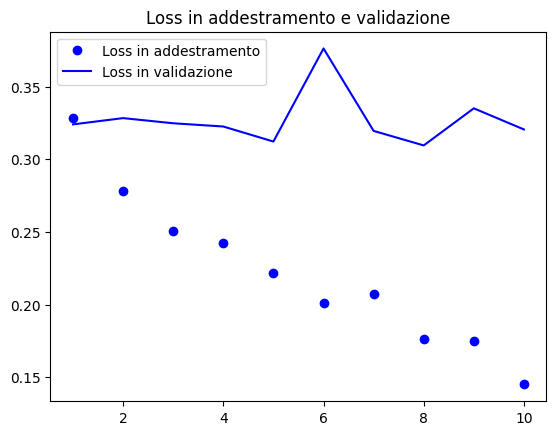

In [ ]:
print(f"\n{model_name} - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip.keras", custom_objects={'preprocess_input':config['preprocess']})
model_mn, history_mn1= train_model(model, model_name, lr=result_mobilenet["lr"], step=1)
plot_history(history_mn1)

il modello ha iniziato ad overfittare quindi non ci sarà uno step 2

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#a causa della lunga durata dell'esecuzione e di un'ora di addestramento parzialmente persa è stato deciso di suddividere l'allenamento in due parti
#config = MODEL_CONFIGS[model_name]
#model_mn = tf.keras.models.load_model(f"results/models/{model_name}_top1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
print(f"\n{model_name} - parte2\n")
model_mn, history_mn2= train_model(model_mn, model_name, lr=result_mobilenet["lr"], step=2)
plot_history(history_mn2)

###fine-tuning

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#config = MODEL_CONFIGS[model_name]
#model_mn = tf.keras.models.load_model(f"results/models/{model_name}_top1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
model_mn.summary()#usato per leggere il nome del layer nella cella successiva

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,244,878 (12.38 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 657,930 (2.51 MB)

In [ ]:
conv_base_mn = model_mn.get_layer("mobilenetv2_1.00_224")

#### iperparametri


In [ ]:
config = MODEL_CONFIGS[model_name]
unfreeze_from_block(conv_base_mn, config["unfreeze_block"])

result_mobilenet_ft=iperparameter_search_ft(model_mn, model_name)


MobileNetV2 - lr=0.0001
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.8943 - loss: 0.2691 - val_accuracy: 0.8799 - val_loss: 0.3245
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9383 - loss: 0.1604 - val_accuracy: 0.8989 - val_loss: 0.2829
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9532 - loss: 0.1264 - val_accuracy: 0.8942 - val_loss: 0.3095
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9604 - loss: 0.1106 - val_accuracy: 0.8957 - val_loss: 0.2984
val_loss: 0.2829 - val_accuracy: 0.8989

MobileNetV2 - lr=1e-05
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9509 - loss: 0.1404 - val_accuracy: 0.8752 - val_loss: 0.3230
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9526 - loss: 0.1218 - val_accuracy: 0.8768 - val_loss: 0.3264
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9600 - loss: 0.1091 - val_accuracy: 0.8942 - val_loss: 0.3016
Epoch 4/4
93/93 ━━━━━━━━━━━━━

In [ ]:
model_mn.set_weights(result_mobilenet_ft["weights"])
model_mn.save(f"results/models/{model_name}_ip_ft.keras")

#### training

In [ ]:
print(f"\n{model_name}_ft - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip_ft.keras", custom_objects={'preprocess_input':config['preprocess']})
model_mn_ft, history_mn_ft1= train_model(model, model_name,lr=result_mobilenet_ft["lr"], step=1, epochs=5, ft=True)
plot_history(history_mn_ft1)


MobileNetV2_ft - parte1

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.9332 - loss: 0.1680 - val_accuracy: 0.8942 - val_loss: 0.3109
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9543 - loss: 0.1223 - val_accuracy: 0.8878 - val_loss: 0.3231
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9698 - loss: 0.0807 - val_accuracy: 0.8910 - val_loss: 0.3783
Epoch 4/5
21/93 ━━━━━━━━━━━━━━━━━━━━ 1:58 2s/step - accuracy: 0.9495 - loss: 0.1110

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#config = MODEL_CONFIGS[model_name]
#model_mn_ft = tf.keras.models.load_model(f"results/models/{model_name}_ft1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
print(f"\n{model_name}_ft - parte2\n")
model_mn_ft, history_mn_ft2= train_model(model_mn_ft, model_name,lr=result_mobilenet_ft["lr"], step=2, epochs=5, ft=True)
plot_history(history_mn_ft2)

##EfficientNetB0

In [ ]:
model_name = "EfficientNetB0"

###Top

####iperparametri

In [ ]:
result_efficientnet1=iperparameter_search(model_name, step=1)


EfficientNetB0 - lr=0.001, dropout=0.2
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.7614 - loss: 0.6070 - val_accuracy: 0.8641 - val_loss: 0.3989
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.8407 - loss: 0.4136 - val_accuracy: 0.8720 - val_loss: 0.3503
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.8709 - loss: 0.3413 - val_accuracy: 0.8910 - val_loss: 0.2995
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.8885 - loss: 0.3075 - val_accuracy: 0.8942 - val_loss: 0.2765
val_loss: 0.2765 - val_accuracy: 0.8942

EfficientNetB0 - lr=0.001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.7377 - loss: 0.6496 - val_accuracy: 0.8341 - val_loss: 0.4344
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step - accuracy: 0.8309 - loss: 0.4431 - val_accuracy: 0.8673 - val_loss: 0.3528
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.8495 - lo

In [ ]:
model_en, conv_base_en = build_model(model_name, dropout=result_efficientnet1["dropout"])
model_en.set_weights(result_efficientnet1["weights"])
model_en.save(f"results/models/{model_name}_ip1.keras")

In [ ]:
result_efficientnet2=iperparameter_search(model_name, step=2)


EfficientNetB0 - lr=0.0001, dropout=0.2
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.6300 - loss: 0.9439 - val_accuracy: 0.7551 - val_loss: 0.6735
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.7645 - loss: 0.6329 - val_accuracy: 0.8325 - val_loss: 0.5244
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.8062 - loss: 0.5358 - val_accuracy: 0.8515 - val_loss: 0.4585
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 334s 3s/step - accuracy: 0.8245 - loss: 0.4909 - val_accuracy: 0.8483 - val_loss: 0.4228
val_loss: 0.4228 - val_accuracy: 0.8515

EfficientNetB0 - lr=0.0001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.5995 - loss: 0.9681 - val_accuracy: 0.7472 - val_loss: 0.6866
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.7465 - loss: 0.6759 - val_accuracy: 0.8009 - val_loss: 0.5581
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.7852 - loss: 0.5749 - val_accuracy: 0.8420 - val_loss: 0.4

In [ ]:
model_en2, conv_base_en2 = build_model(model_name, dropout=result_efficientnet2["dropout"])
model_en2.set_weights(result_efficientnet2["weights"])
model_en2.save(f"results/models/{model_name}_ip2.keras")

In [ ]:
model_en.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

model_en2.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

res1_loss, _ = model_en.evaluate(validation_dataset)
res2_loss, _ = model_en2.evaluate(validation_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8942 - loss: 0.2765
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8483 - loss: 0.4228


In [ ]:
if res1_loss<res2_loss:
  best=model_en
  print(f"{result_efficientnet1["lr"]} {result_efficientnet1["dropout"]}")
  result_efficientnet=result_efficientnet1
else:
  best=model_en2
  print(f"{result_efficientnet2["lr"]} {result_efficientnet2["dropout"]}")
  result_efficientnet=result_efficientnet2
best.save(f"results/models/{model_name}_ip.keras")

0.001 0.2


####training


EfficientNetB0 - parte1

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


93/93 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - accuracy: 0.8797 - loss: 0.3048 - val_accuracy: 0.8973 - val_loss: 0.2857
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 306s 3s/step - accuracy: 0.8885 - loss: 0.2823 - val_accuracy: 0.8831 - val_loss: 0.2904
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.8997 - loss: 0.2641 - val_accuracy: 0.8894 - val_loss: 0.2647
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.9068 - loss: 0.2555 - val_accuracy: 0.8989 - val_loss: 0.2596
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - accuracy: 0.9095 - loss: 0.2479 - val_accuracy: 0.8705 - val_loss: 0.3085
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.9149 - loss: 0.2236 - val_accuracy: 0.9052 - val_loss: 0.2402
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.9180 - loss: 0.2054 - val_accuracy: 0.8957 - val_loss: 0.2737
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.9261 - loss: 0.1991 - val_accuracy: 0.8831 - val_loss: 0.

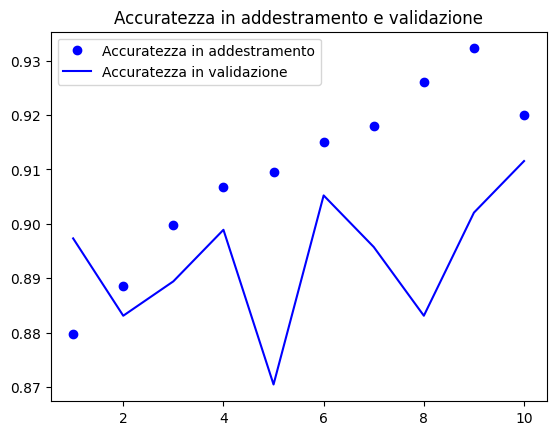

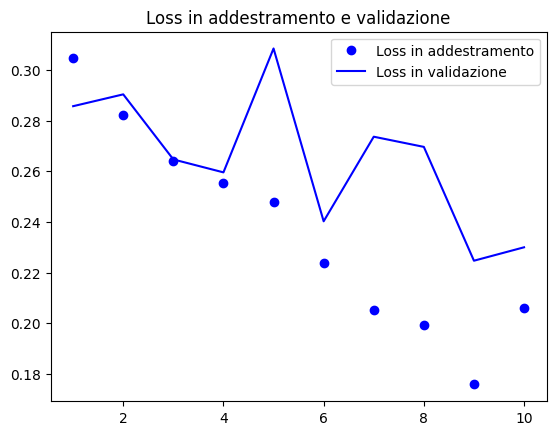

In [ ]:
print(f"\n{model_name} - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip.keras", custom_objects={'preprocess_input':config['preprocess']})
model_en, history_en1= train_model(model, model_name,lr=result_efficientnet["lr"], step=1)
plot_history(history_en1)

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#config = MODEL_CONFIGS[model_name]
#model_en = tf.keras.models.load_model(f"results/models/{model_name}_top1.keras", custom_objects={'preprocess_input':config['preprocess']})


EfficientNetB0 - part2

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.9231 - loss: 0.2080 - val_accuracy: 0.9068 - val_loss: 0.2462
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.9329 - loss: 0.1761 - val_accuracy: 0.9052 - val_loss: 0.2246
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.9315 - loss: 0.1695 - val_accuracy: 0.8894 - val_loss: 0.2720
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.9343 - loss: 0.1725 - val_accuracy: 0.8926 - val_loss: 0.2526
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.9424 - loss: 0.1583 - val_accuracy: 0.9005 - val_loss: 0.2481


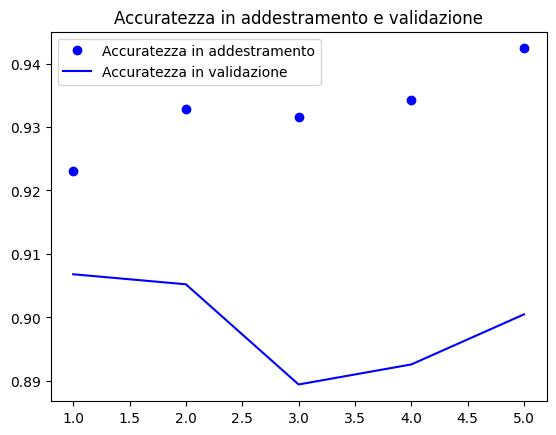

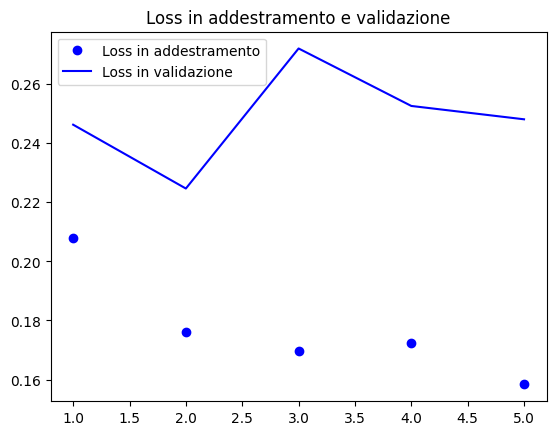

In [ ]:
print(f"\n{model_name} - part2\n")

model_en, history_en2= train_model(model_en, model_name,lr=result_efficientnet["lr"], step=2)
plot_history(history_en2)

###finetuning

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#config = MODEL_CONFIGS[model_name]
#model_en = tf.keras.models.load_model(f"results/models/{model_name}_top2.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
model_en.summary() #usato per leggere il nome del layer nella cella successiva

Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,036,465 (19.21 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 657,930 (2.51 MB)

In [ ]:
conv_base_en = model_en.get_layer("efficientnetb0")

####iperparametri

In [ ]:
config = MODEL_CONFIGS[model_name]
unfreeze_from_block(conv_base_en, config["unfreeze_block"])

result_efficientnet_ft=iperparameter_search_ft(model_en, model_name)


EfficientNetB0 - lr=0.0001
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.9241 - loss: 0.1945 - val_accuracy: 0.9100 - val_loss: 0.2186
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.9468 - loss: 0.1417 - val_accuracy: 0.9131 - val_loss: 0.2268
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 321s 3s/step - accuracy: 0.9509 - loss: 0.1270 - val_accuracy: 0.9068 - val_loss: 0.2411
val_loss: 0.2186 - val_accuracy: 0.9131

EfficientNetB0 - lr=1e-05
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.9502 - loss: 0.1354 - val_accuracy: 0.9100 - val_loss: 0.2199
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.9583 - loss: 0.1298 - val_accuracy: 0.9131 - val_loss: 0.2182
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.9553 - loss: 0.1259 - val_accuracy: 0.9147 - val_loss: 0.2208
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.9576 - loss: 0.1228 - val_accuracy: 0.9147 - val_loss: 0.2211
val_loss: 0.2182 - val_

In [ ]:
model_en.set_weights(result_efficientnet_ft["weights"])
model_en.save(f"results/models/{model_name}_ip_ft.keras")

####training



EfficientNetB0_ft - parte1

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.9512 - loss: 0.1288 - val_accuracy: 0.9036 - val_loss: 0.2208
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.9553 - loss: 0.1262 - val_accuracy: 0.9084 - val_loss: 0.2229
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.9573 - loss: 0.1162 - val_accuracy: 0.9179 - val_loss: 0.2148
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.9614 - loss: 0.1169 - val_accuracy: 0.9163 - val_loss: 0.2195
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.9604 - loss: 0.1130 - val_accuracy: 0.9131 - val_loss: 0.2210


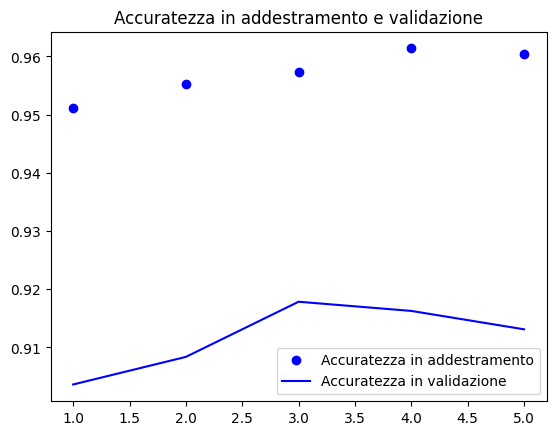

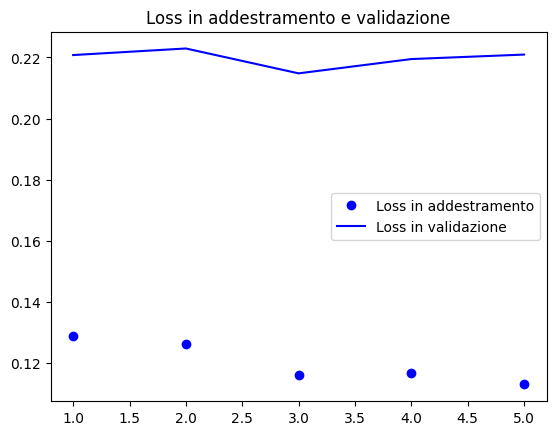

In [ ]:
print(f"\n{model_name}_ft - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip_ft.keras", custom_objects={'preprocess_input':config['preprocess']})
model_en_ft, history_en_ft1= train_model(model, model_name,lr=result_efficientnet_ft["lr"], step=1, epochs=5, ft=True)
plot_history(history_en_ft1)

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME
#config = MODEL_CONFIGS[model_name]
#model_en_ft = tf.keras.models.load_model(f"results/models/{model_name}_ft1.keras", custom_objects={'preprocess_input':config['preprocess']})


EfficientNetB0_ft - parte2

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.9593 - loss: 0.1136 - val_accuracy: 0.9021 - val_loss: 0.2249
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.9583 - loss: 0.1186 - val_accuracy: 0.9100 - val_loss: 0.2158
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 348s 3s/step - accuracy: 0.9604 - loss: 0.1077 - val_accuracy: 0.9179 - val_loss: 0.2178
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 637s 7s/step - accuracy: 0.9604 - loss: 0.1076 - val_accuracy: 0.9115 - val_loss: 0.2157
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.9631 - loss: 0.1101 - val_accuracy: 0.9147 - val_loss: 0.2185


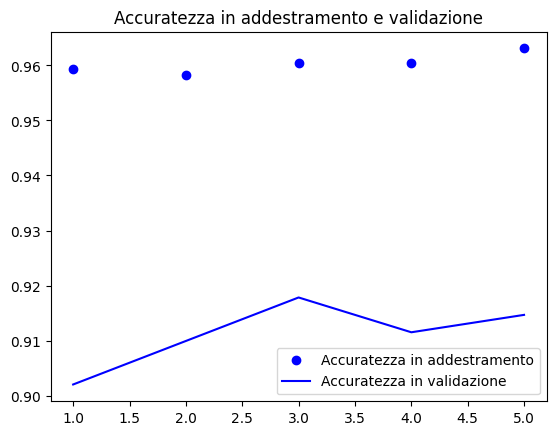

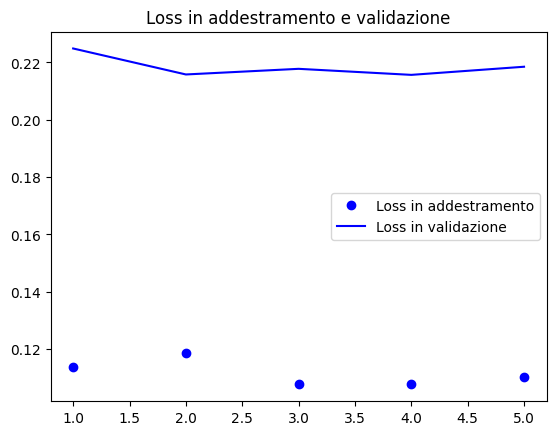

In [ ]:
print(f"\n{model_name}_ft - parte2\n")
model_en_ft, history_en_ft2= train_model(model_en_ft, model_name,lr=result_efficientnet_ft["lr"], step=2, epochs=5, ft=True)
plot_history(history_en_ft2)

##ResNet50V2

In [ ]:
model_name = "ResNet50V2"

###Top

####iperparametri

In [ ]:
result_resnet1=iperparameter_search(model_name, step=1)


ResNet50V2 - lr=0.001, dropout=0.2
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 605s 6s/step - accuracy: 0.7343 - loss: 0.6649 - val_accuracy: 0.7899 - val_loss: 0.5159
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 580s 6s/step - accuracy: 0.8184 - loss: 0.4636 - val_accuracy: 0.7946 - val_loss: 0.5042
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 608s 6s/step - accuracy: 0.8492 - loss: 0.3863 - val_accuracy: 0.7978 - val_loss: 0.4782
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 597s 6s/step - accuracy: 0.8706 - loss: 0.3317 - val_accuracy: 0.8436 - val_loss: 0.3856
val_loss: 0.3856 - val_accuracy: 0.8436

ResNet50V2 - lr=0.001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 602s 6s/step - accuracy: 0.7177 - loss: 0.7201 - val_accuracy: 0.7646 - val_loss: 0.5854
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 590s 6s/step - accuracy: 0.8041 - loss: 0.5102 - val_accuracy: 0.7567 - val_loss: 0.5674
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 592s 6s/step - accuracy: 0.8289 - loss: 0.43

In [ ]:
model_rn, conv_base_rn = build_model(model_name, dropout=result_resnet1["dropout"])
model_rn.set_weights(result_resnet1["weights"])
model_rn.save(f"results/models/{model_name}_ip1.keras")

In [ ]:
result_resnet2=iperparameter_search(model_name, step=2)


ResNet50V2 - lr=0.0001, dropout=0.2
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 554s 6s/step - accuracy: 0.6181 - loss: 0.9300 - val_accuracy: 0.7520 - val_loss: 0.6393
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 549s 6s/step - accuracy: 0.7584 - loss: 0.6073 - val_accuracy: 0.7804 - val_loss: 0.5499
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 605s 6s/step - accuracy: 0.7967 - loss: 0.5233 - val_accuracy: 0.7962 - val_loss: 0.5125
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 543s 6s/step - accuracy: 0.8224 - loss: 0.4673 - val_accuracy: 0.8152 - val_loss: 0.4828
val_loss: 0.4828 - val_accuracy: 0.8152

ResNet50V2 - lr=0.0001, dropout=0.4
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 600s 6s/step - accuracy: 0.5788 - loss: 1.0362 - val_accuracy: 0.7378 - val_loss: 0.6488
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 590s 6s/step - accuracy: 0.7326 - loss: 0.6626 - val_accuracy: 0.7694 - val_loss: 0.5620
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 591s 6s/step - accuracy: 0.7753 - loss: 0.5850 - val_accuracy: 0.7915 - val_loss: 0.5227
Epoc

In [ ]:
model_rn2, conv_base_rn2 = build_model(model_name, dropout=result_resnet2["dropout"])
model_rn2.set_weights(result_resnet2["weights"])
model_rn2.save(f"results/models/{model_name}_ip2.keras")

In [ ]:
model_rn.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

model_rn2.compile(
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

res1_loss, _ = model_rn.evaluate(validation_dataset)
res2_loss, _ = model_rn2.evaluate(validation_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.8436 - loss: 0.3856
20/20 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.8152 - loss: 0.4828


In [ ]:
if res1_loss<res2_loss:
  best=model_rn
  print(f"{result_resnet1["lr"]} {result_resnet1["dropout"]}")
  result_resnet=result_resnet1
else:
  best=model_rn2
  print(f"{result_resnet2["lr"]} {result_resnet2["dropout"]}")
  result_resnet=result_resnet2
best.save(f"results/models/{model_name}_ip.keras")

0.001 0.2


####training



ResNet50V2 - parte1

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


93/93 ━━━━━━━━━━━━━━━━━━━━ 572s 6s/step - accuracy: 0.8780 - loss: 0.3080 - val_accuracy: 0.8357 - val_loss: 0.4114
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 604s 7s/step - accuracy: 0.9011 - loss: 0.2583 - val_accuracy: 0.8626 - val_loss: 0.3763
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 554s 6s/step - accuracy: 0.9109 - loss: 0.2281 - val_accuracy: 0.8657 - val_loss: 0.3475
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 599s 6s/step - accuracy: 0.9248 - loss: 0.1925 - val_accuracy: 0.8736 - val_loss: 0.3327
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 612s 7s/step - accuracy: 0.9383 - loss: 0.1719 - val_accuracy: 0.8594 - val_loss: 0.3746
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 601s 6s/step - accuracy: 0.9465 - loss: 0.1507 - val_accuracy: 0.8768 - val_loss: 0.3312
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 596s 6s/step - accuracy: 0.9526 - loss: 0.1268 - val_accuracy: 0.8847 - val_loss: 0.3198
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 551s 6s/step - accuracy: 0.9539 - loss: 0.1260 - val_accuracy: 0.8736 - val_loss: 0.

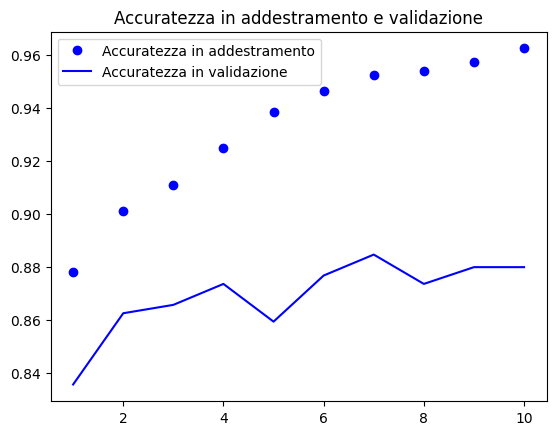

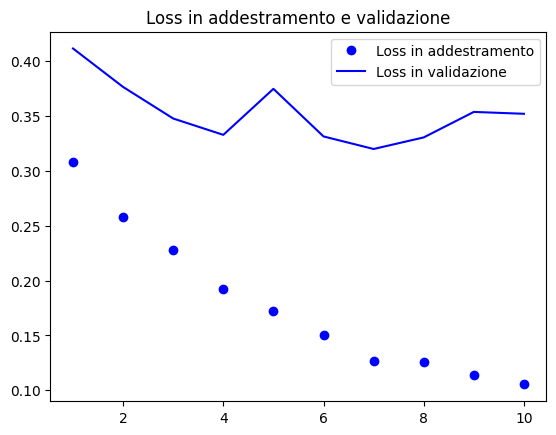

In [ ]:
print(f"\n{model_name} - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip.keras", custom_objects={'preprocess_input':config['preprocess']})
model_rn, history_rn1= train_model(model, model_name,lr=result_resnet["lr"], step=1)
plot_history(history_rn1)

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME

#config = MODEL_CONFIGS[model_name]
#model_rn = tf.keras.models.load_model(f"results/models/ResNet50V2_top1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
print(f"\n{model_name} - parte2\n")

model_rn, history_rn2= train_model(model_rn, model_name,lr=result_resnet["lr"], step=2)
plot_history(history_rn2)

###finetuning

In [ ]:
#USARE SOLO IN CASO DI RESTART RUNTIME

#config = MODEL_CONFIGS[model_name]
#model_rn = tf.keras.models.load_model(f"results/models/{model_name}_top1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
model_rn.summary()#usato per leggere il nome del layer nella cella successiva

Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,141,518 (95.91 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

 Optimizer params: 1,051,146 (4.01 MB)

In [ ]:
conv_base_rn = model_rn.get_layer("resnet50v2")

####iperparametri

In [ ]:

config = MODEL_CONFIGS[model_name]
unfreeze_from_block(conv_base_rn, config["unfreeze_block"])

result_resnet_ft=iperparameter_search_ft(model_rn, model_name)


ResNet50V2 - lr=0.0001
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 633s 7s/step - accuracy: 0.9285 - loss: 0.1915 - val_accuracy: 0.8989 - val_loss: 0.2875
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 660s 7s/step - accuracy: 0.9770 - loss: 0.0725 - val_accuracy: 0.9036 - val_loss: 0.3084
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 658s 7s/step - accuracy: 0.9909 - loss: 0.0339 - val_accuracy: 0.8736 - val_loss: 0.4490
val_loss: 0.2875 - val_accuracy: 0.9036

ResNet50V2 - lr=1e-05
Epoch 1/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 620s 7s/step - accuracy: 0.9654 - loss: 0.0916 - val_accuracy: 0.8973 - val_loss: 0.3107
Epoch 2/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 656s 7s/step - accuracy: 0.9783 - loss: 0.0663 - val_accuracy: 0.8989 - val_loss: 0.3152
Epoch 3/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 661s 7s/step - accuracy: 0.9902 - loss: 0.0445 - val_accuracy: 0.9068 - val_loss: 0.3034
Epoch 4/4
93/93 ━━━━━━━━━━━━━━━━━━━━ 615s 7s/step - accuracy: 0.9953 - loss: 0.0345 - val_accuracy: 0.9068 - val_loss: 0.3073
val_loss: 0.3034 - val_accuracy

In [ ]:
model_rn.set_weights(result_resnet_ft["weights"])
model_rn.save(f"results/models/{model_name}_ip_ft.keras")

####training


ResNet50V2_ft - parte1

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 628s 7s/step - accuracy: 0.9627 - loss: 0.1089 - val_accuracy: 0.8831 - val_loss: 0.3372
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 632s 7s/step - accuracy: 0.9851 - loss: 0.0466 - val_accuracy: 0.9005 - val_loss: 0.3571
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 673s 7s/step - accuracy: 0.9942 - loss: 0.0181 - val_accuracy: 0.8799 - val_loss: 0.4481
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 665s 7s/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.8989 - val_loss: 0.3682


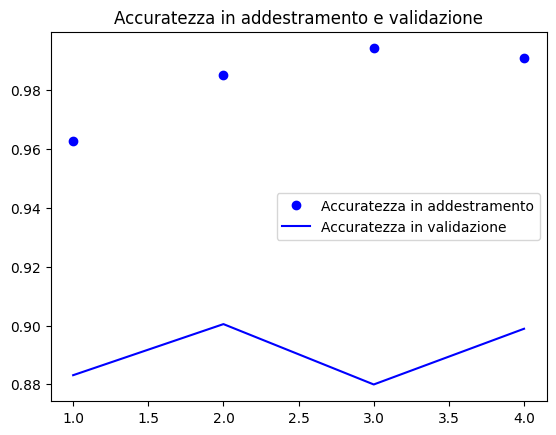

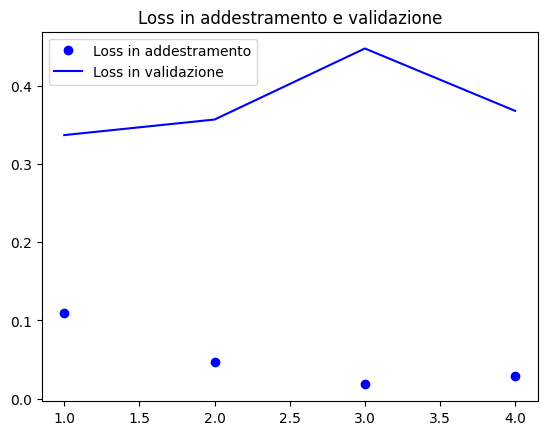

In [ ]:
print(f"\n{model_name}_ft - parte1\n")
config = MODEL_CONFIGS[model_name]
model= tf.keras.models.load_model(f"results/models/{model_name}_ip_ft.keras", custom_objects={'preprocess_input':config['preprocess']})
model_rn_ft, history_rn_ft1= train_model(model, model_name,lr=result_resnet_ft["lr"], step=1, epochs=5, ft=True)
plot_history(history_rn_ft1)

In [ ]:
#config = MODEL_CONFIGS[model_name]
#model_rn_ft= tf.keras.models.load_model(f"results/models/{model_name}_ft1.keras", custom_objects={'preprocess_input':config['preprocess']})

In [ ]:
print(f"\n{model_name}_ft - parte2\n")
model_rn_ft, history_rn_ft2= train_model(model_rn_ft, model_name,lr=result_resnet_ft["lr"], step=2, epochs=5, ft=True)
plot_history(history_rn_ft2)